In [1]:
# ── 1. Imports ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

plt.style.use("dark_background")
sns.set_palette("husl")
print("✅ All libraries imported successfully")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")


✅ All libraries imported successfully
   pandas 3.0.2 | numpy 2.4.4


In [2]:
# Load dataset
DATA_PATH = "data/violations.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nDtypes:")
print(df.dtypes)


Shape      : (298450, 24)
Columns    : ['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'description', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp']

Dtypes:
id                                  str
latitude                        float64
longitude                       float64
location                            str
vehicle_number                      str
vehicle_type                        str
description                     float64
violation_type                      str
offence_code                        str
created_datetime                    str
closed_datetime                 float64
modified_datetime                   str
device_id                     

In [3]:
df.head(3)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00


In [4]:
# Basic info
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_report[missing_report["Missing Count"] > 0].to_string())
print(f"\nTotal rows  : {len(df):,}")
print(f"Total columns: {len(df.columns)}")


=== MISSING VALUES ===
                              Missing Count  Missing %
location                               3041       1.02
description                          298450     100.00
closed_datetime                      298450     100.00
created_by_id                             5       0.00
center_code                           11260       3.77
police_station                            5       0.00
junction_name                             5       0.00
action_taken_timestamp               298450     100.00
data_sent_to_scita_timestamp         256289      85.87
updated_vehicle_number               125254      41.97
updated_vehicle_type                 125254      41.97
validation_status                    125254      41.97
validation_timestamp                 125254      41.97

Total rows  : 298,450
Total columns: 24


In [5]:
# Violation type distribution
print("=== TOP 10 VIOLATION TYPES ===")
df["violation_clean"] = (
    df["violation_type"].fillna("UNKNOWN")
    .str.replace(r'[\[\]\"]', "", regex=True).str.strip()
)
df["primary_violation"] = df["violation_clean"].str.split(",").str[0].str.strip()
print(df["primary_violation"].value_counts().head(10).to_string())


=== TOP 10 VIOLATION TYPES ===


primary_violation
WRONG PARKING                                147493
NO PARKING                                   128624
PARKING IN A MAIN ROAD                        17084
PARKING ON FOOTPATH                            2447
DEFECTIVE NUMBER PLATE                          807
PARKING NEAR ROAD CROSSING                      646
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         594
DOUBLE PARKING                                  316
PARKING OTHER THAN BUS STOP                     194
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS       125


In [6]:
# ── 2a. Parse datetime & extract features ─────────────────
df["created_datetime"] = pd.to_datetime(df["created_datetime"], utc=True, errors="coerce")
df["hour"]    = df["created_datetime"].dt.hour
df["month"]   = df["created_datetime"].dt.month
df["dow_num"] = df["created_datetime"].dt.dayofweek

# ── 2b. Parking flag & impact score ───────────────────────
PARKING_KEYWORDS = ["PARKING", "NO PARKING", "WRONG PARKING", "FOOTPATH"]
df["is_parking"] = df["violation_clean"].str.contains("|".join(PARKING_KEYWORDS), case=False, na=False)

def impact_score(row):
    v = str(row["violation_clean"]).upper()
    if "MAIN ROAD" in v:           return 3   # blocks carriageway
    if "FOOTPATH" in v or "DOUBLE" in v or "BUSTOP" in v: return 2
    if "NO PARKING" in v or "WRONG PARKING" in v: return 1
    return 0

df["impact_score"] = df.apply(impact_score, axis=1)

# Filter to parking violations only
parking = df[df["is_parking"]].copy()
parking = parking.dropna(subset=["latitude","longitude","vehicle_type","police_station"])
parking = parking[
    (parking["latitude"]  > 12.7) & (parking["latitude"]  < 13.4) &
    (parking["longitude"] > 77.4) & (parking["longitude"] < 77.9)
]

print(f"Parking violations after cleaning: {len(parking):,}")
print(f"Dropped rows: {len(df[df['is_parking']]) - len(parking):,}")


Parking violations after cleaning: 298,445
Dropped rows: 5


In [7]:
# ── 2c. Feature Engineering ───────────────────────────────
# Binary junction proximity flag
parking["near_junction"] = (parking["junction_name"] != "No Junction").astype(int)

# Area density (violations per ~500m grid cell)
grid = 0.005
parking["lat_bin"] = (parking["latitude"]  / grid).round() * grid
parking["lon_bin"] = (parking["longitude"] / grid).round() * grid
parking["area_density"] = parking.groupby(["lat_bin","lon_bin"])["id"].transform("count")

# ── 2d. Encode categoricals ────────────────────────────────
le_veh = LabelEncoder()
le_sta = LabelEncoder()
parking["vehicle_enc"] = le_veh.fit_transform(parking["vehicle_type"].fillna("UNKNOWN"))
parking["station_enc"] = le_sta.fit_transform(parking["police_station"].fillna("UNKNOWN"))

# Show encoding sample
enc_sample = pd.DataFrame({
    "Vehicle Type":   le_veh.classes_[:8],
    "Encoded Value":  range(8),
})
print("=== Label Encoding (Vehicle Type — first 8) ===")
print(enc_sample.to_string(index=False))


=== Label Encoding (Vehicle Type — first 8) ===
       Vehicle Type  Encoded Value
   BUS (BMTC/KSRTC)              0
                CAR              1
        FACTORY BUS              2
         GOODS AUTO              3
                HGV              4
               JEEP              5
                LGV              6
LORRY/GOODS VEHICLE              7


In [8]:
# ── 2e. Define Feature Matrix & Target ───────────────────
FEATURES = [
    "hour", "month", "dow_num",
    "latitude", "longitude",
    "vehicle_enc", "station_enc",
    "near_junction", "area_density",
]
TARGET = "is_high_impact"

parking[TARGET] = (parking["impact_score"] == 3).astype(int)

X = parking[FEATURES].copy()
y = parking[TARGET].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  :")
print(y.value_counts().rename({0: "LOW/MEDIUM (0)", 1: "HIGH Impact (1)"}).to_string())
print(f"\nClass imbalance ratio: {(y==0).sum() / (y==1).sum():.1f}:1")


Feature matrix shape : (298445, 9)
Target distribution  :
is_high_impact
LOW/MEDIUM (0)     274502
HIGH Impact (1)     23943

Class imbalance ratio: 11.5:1


In [9]:
# ── 2f. Missing value imputation + scaling ────────────────
print("=== Missing values in feature matrix ===")
print(X.isnull().sum().to_string())

imputer = SimpleImputer(strategy="median")
X_imp   = imputer.fit_transform(X)

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print("\n✅ Imputation  : SimpleImputer(strategy='median')")
print("✅ Scaling     : StandardScaler (mean=0, std=1)")
print(f"   Feature means (post-scale): {X_scaled.mean(axis=0).round(4)}")


=== Missing values in feature matrix ===
hour             0
month            0
dow_num          0
latitude         0
longitude        0
vehicle_enc      0
station_enc      0
near_junction    0
area_density     0



✅ Imputation  : SimpleImputer(strategy='median')
✅ Scaling     : StandardScaler (mean=0, std=1)
   Feature means (post-scale): [ 0.  0. -0. -0. -0. -0. -0. -0. -0.]


In [10]:
# ── 2g. Train / Test Split ────────────────────────────────
MAX_ROWS = 60_000
if len(X_scaled) > MAX_ROWS:
    idx = np.random.RandomState(42).choice(len(X_scaled), MAX_ROWS, replace=False)
    X_s, y_s = X_scaled[idx], y.iloc[idx].reset_index(drop=True)
else:
    X_s, y_s = X_scaled, y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s, test_size=0.20, random_state=42, stratify=y_s
)

print(f"Total samples (capped): {len(X_s):,}")
print(f"Training set : {len(X_train):,} rows  ({len(X_train)/len(X_s)*100:.0f}%)")
print(f"Test set     : {len(X_test):,}  rows  ({len(X_test)/len(X_s)*100:.0f}%)")
print(f"\nClass balance in train — HIGH: {y_train.sum():,}  LOW/MED: {(y_train==0).sum():,}")
print(f"Class balance in test  — HIGH: {y_test.sum():,}   LOW/MED: {(y_test==0).sum():,}")


Total samples (capped): 60,000
Training set : 48,000 rows  (80%)
Test set     : 12,000  rows  (20%)

Class balance in train — HIGH: 3,835  LOW/MED: 44,165
Class balance in test  — HIGH: 959   LOW/MED: 11,041


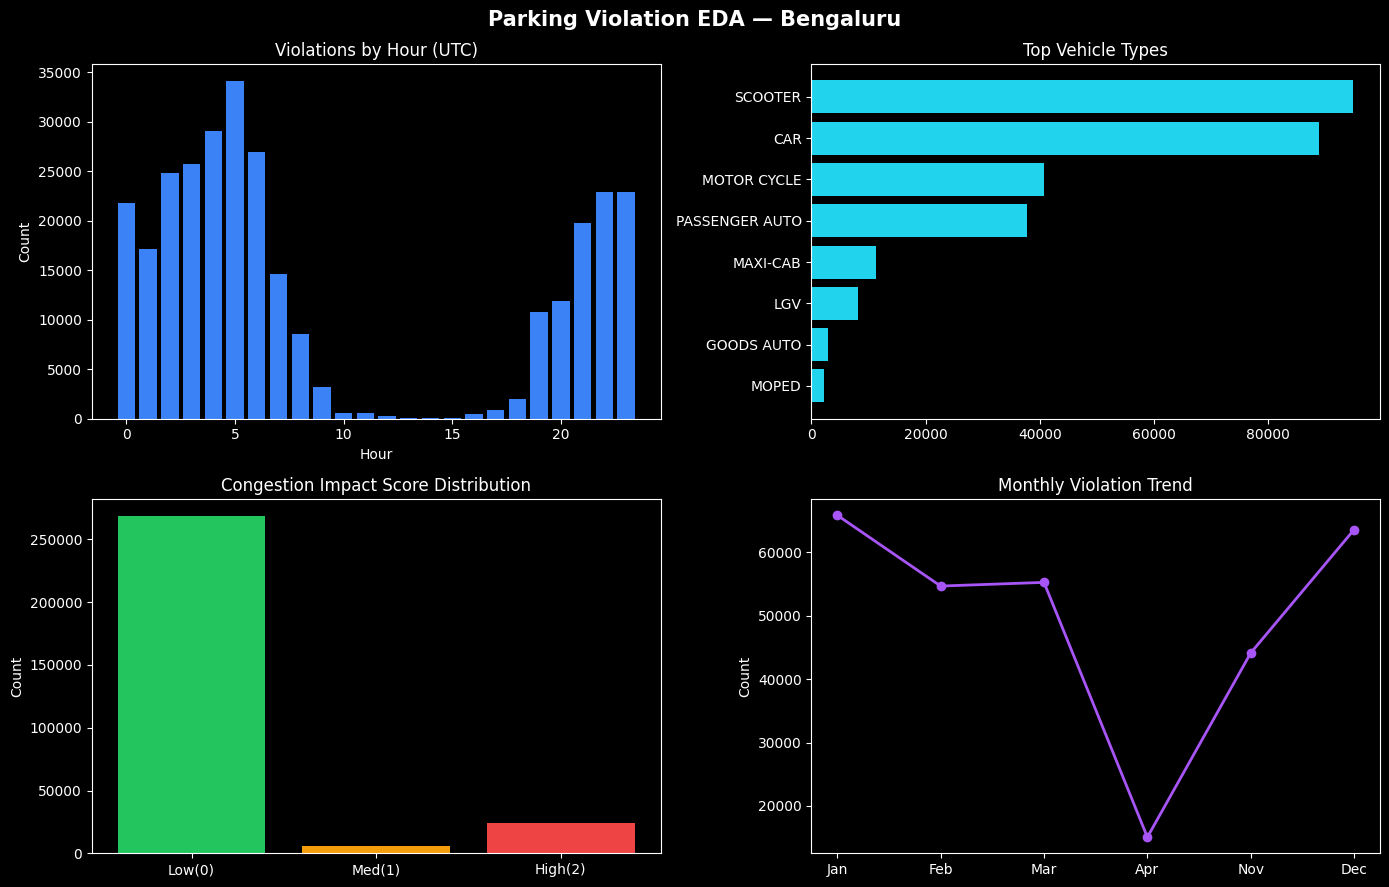

✅ EDA charts saved to data/eda_charts.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Parking Violation EDA — Bengaluru", fontsize=15, fontweight="bold", color="white")

# 1. Hourly distribution
hourly = parking.groupby("hour").size()
axes[0,0].bar(hourly.index, hourly.values, color="#3b82f6", edgecolor="none")
axes[0,0].set_title("Violations by Hour (UTC)", color="white")
axes[0,0].set_xlabel("Hour"); axes[0,0].set_ylabel("Count")

# 2. Vehicle type
veh_counts = parking["vehicle_type"].value_counts().head(8)
axes[0,1].barh(veh_counts.index, veh_counts.values, color="#22d3ee")
axes[0,1].set_title("Top Vehicle Types", color="white")
axes[0,1].invert_yaxis()

# 3. Impact score distribution
impact_counts = parking["impact_score"].value_counts().sort_index()
colors = ["#22c55e","#f59e0b","#ef4444","#7c3aed"]
axes[1,0].bar(["Low(0)","Med(1)","High(2)","VHigh(3)"][:len(impact_counts)],
              impact_counts.values, color=colors[:len(impact_counts)])
axes[1,0].set_title("Congestion Impact Score Distribution", color="white")
axes[1,0].set_ylabel("Count")

# 4. Monthly trend
monthly = parking.groupby("month").size()
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",11:"Nov",12:"Dec"}
axes[1,1].plot(
    [month_names.get(m, str(m)) for m in sorted(monthly.index)],
    [monthly[m] for m in sorted(monthly.index)],
    marker="o", color="#a855f7", linewidth=2
)
axes[1,1].set_title("Monthly Violation Trend", color="white")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("data/eda_charts.png", dpi=120, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("✅ EDA charts saved to data/eda_charts.png")


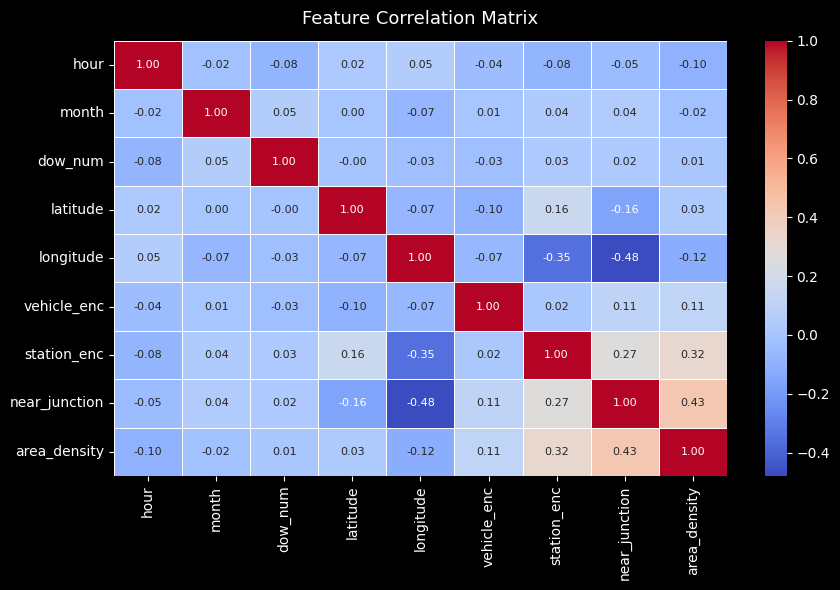

In [12]:
# Correlation heatmap of features
fig, ax = plt.subplots(figsize=(9, 6))
corr = pd.DataFrame(X_scaled, columns=FEATURES).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
            linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", color="white", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=120, bbox_inches="tight", facecolor="#0f172a")
plt.show()


In [13]:
# ── Train Random Forest ───────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest trained")

# ── Train Gradient Boosting (for comparison) ───────────────
print("\nTraining Gradient Boosting (benchmark)...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print("✅ Gradient Boosting trained")


Training Random Forest...


✅ Random Forest trained

Training Gradient Boosting (benchmark)...


✅ Gradient Boosting trained


In [14]:
# ── Classification Report ─────────────────────────────────
print("=" * 55)
print("  RANDOM FOREST — Classification Report")
print("=" * 55)
print(classification_report(
    y_test, y_pred_rf,
    target_names=["LOW/MEDIUM Impact", "HIGH Impact (Main Road)"]
))


  RANDOM FOREST — Classification Report
                         precision    recall  f1-score   support

      LOW/MEDIUM Impact       0.98      0.89      0.93     11041
HIGH Impact (Main Road)       0.37      0.77      0.50       959

               accuracy                           0.88     12000
              macro avg       0.68      0.83      0.72     12000
           weighted avg       0.93      0.88      0.90     12000



In [15]:
# ── Summary metric table ──────────────────────────────────
def metrics_summary(y_true, y_pred, name):
    return {
        "Model"       : name,
        "Accuracy"    : f"{accuracy_score(y_true, y_pred)*100:.2f}%",
        "Precision"   : f"{precision_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
        "Recall"      : f"{recall_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
        "F1-Score"    : f"{f1_score(y_true, y_pred, average='weighted', zero_division=0)*100:.2f}%",
        "F1 (HIGH cls)": f"{f1_score(y_true, y_pred, pos_label=1, zero_division=0)*100:.2f}%",
    }

results = pd.DataFrame([
    metrics_summary(y_test, y_pred_rf, "Random Forest"),
    metrics_summary(y_test, y_pred_gb, "Gradient Boosting"),
])
print(results.to_string(index=False))


            Model Accuracy Precision Recall F1-Score F1 (HIGH cls)
    Random Forest   87.88%    92.95% 87.88%   89.67%        50.29%
Gradient Boosting   94.09%    93.40% 94.09%   93.05%        49.10%


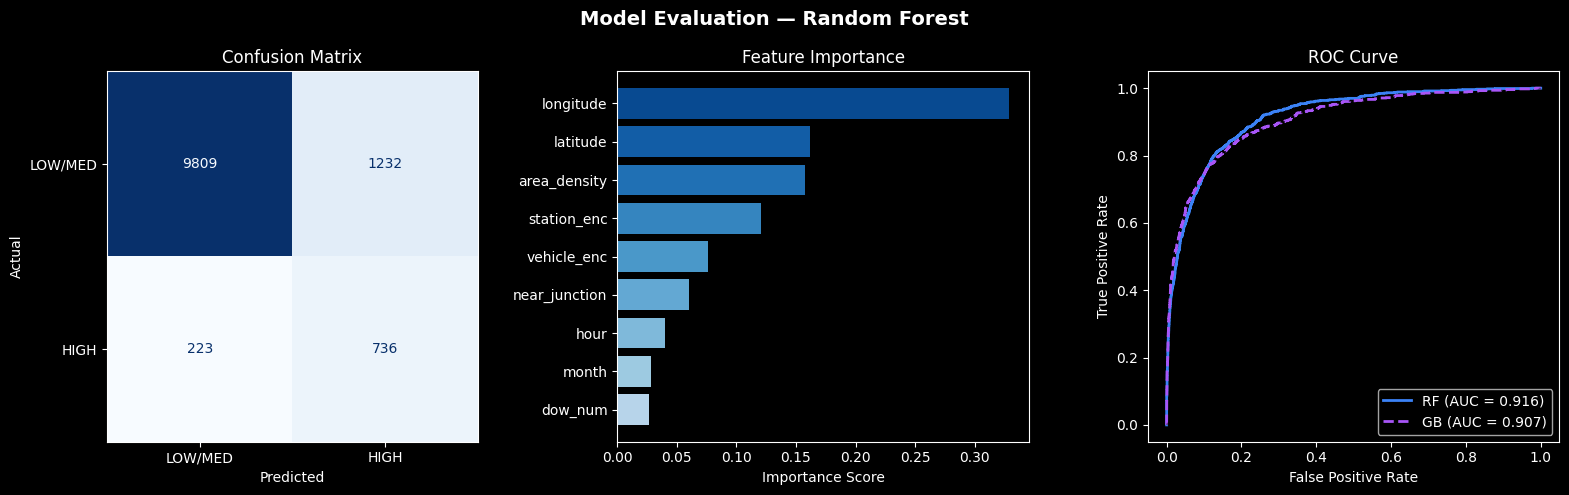


✅ AUC-ROC: 0.9159


In [16]:
# ── Confusion Matrix & ROC ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation — Random Forest", fontsize=14, fontweight="bold", color="white")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=["LOW/MED", "HIGH"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", color="white")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Feature importance
fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
axes[1].barh(fi.index, fi.values, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(fi))))
axes[1].set_title("Feature Importance", color="white")
axes[1].set_xlabel("Importance Score")

# ROC curve
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#3b82f6", lw=2, label=f"RF (AUC = {roc_auc:.3f})")
y_prob_gb = gb_model.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
axes[2].plot(fpr_gb, tpr_gb, color="#a855f7", lw=2, linestyle="--",
             label=f"GB (AUC = {auc(fpr_gb, tpr_gb):.3f})")
axes[2].plot([0,1],[0,1],"k--", alpha=0.4)
axes[2].set_title("ROC Curve", color="white")
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.savefig("data/model_evaluation.png", dpi=120, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print(f"\n✅ AUC-ROC: {roc_auc:.4f}")


Running 5-Fold Stratified Cross-Validation on Random Forest...



CV F1 scores : [np.float64(0.8909), np.float64(0.8957), np.float64(0.8904), np.float64(0.8954), np.float64(0.8953)]
Mean F1      : 0.8935
Std Dev      : 0.0024
95% CI       : [0.8888, 0.8983]


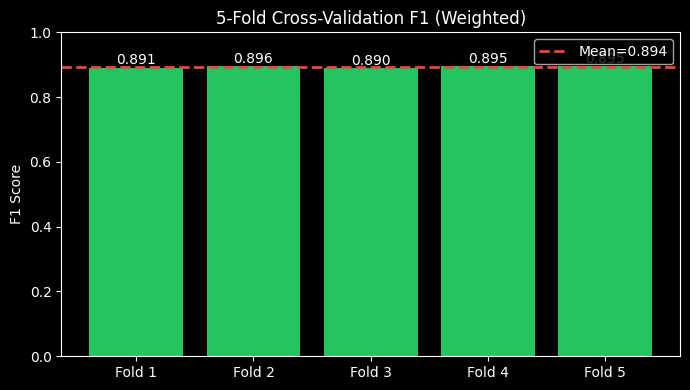

In [17]:
# ── 5-Fold Cross Validation ───────────────────────────────
print("Running 5-Fold Stratified Cross-Validation on Random Forest...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_s, y_s, cv=cv, scoring="f1_weighted", n_jobs=-1)

print(f"\nCV F1 scores : {[round(s,4) for s in cv_scores]}")
print(f"Mean F1      : {cv_scores.mean():.4f}")
print(f"Std Dev      : {cv_scores.std():.4f}")
print(f"95% CI       : [{cv_scores.mean()-2*cv_scores.std():.4f}, {cv_scores.mean()+2*cv_scores.std():.4f}]")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f"Fold {i+1}" for i in range(5)], cv_scores, color="#22c55e", edgecolor="none")
ax.axhline(cv_scores.mean(), color="#ef4444", linestyle="--", lw=2, label=f"Mean={cv_scores.mean():.3f}")
ax.set_ylim(0, 1); ax.set_title("5-Fold Cross-Validation F1 (Weighted)", color="white")
ax.set_ylabel("F1 Score"); ax.legend()
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{score:.3f}", ha="center", fontsize=10, color="white")
plt.tight_layout()
plt.savefig("data/cross_validation.png", dpi=120, bbox_inches="tight", facecolor="#0f172a")
plt.show()


In [18]:
# Save model + preprocessing objects
import joblib, json

joblib.dump(rf_model,  "model.pkl")
joblib.dump(imputer,   "data/imputer.pkl")
joblib.dump(scaler,    "data/scaler.pkl")
joblib.dump(le_veh,    "data/le_vehicle.pkl")
joblib.dump(le_sta,    "data/le_station.pkl")

# Save feature metadata
metadata = {
    "features"       : FEATURES,
    "target"         : TARGET,
    "model"          : "RandomForestClassifier",
    "n_estimators"   : 150,
    "max_depth"      : 10,
    "class_weight"   : "balanced",
    "train_rows"     : int(len(X_train)),
    "test_rows"      : int(len(X_test)),
    "accuracy"       : round(accuracy_score(y_test, y_pred_rf), 4),
    "f1_weighted"    : round(f1_score(y_test, y_pred_rf, average="weighted"), 4),
    "f1_high_impact" : round(f1_score(y_test, y_pred_rf, pos_label=1), 4),
    "auc_roc"        : round(float(roc_auc), 4),
    "cv_f1_mean"     : round(float(cv_scores.mean()), 4),
    "cv_f1_std"      : round(float(cv_scores.std()), 4),
}
with open("data/model_metadata.json","w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved artifacts:")
for path in ["model.pkl","data/imputer.pkl","data/scaler.pkl",
             "data/le_vehicle.pkl","data/le_station.pkl","data/model_metadata.json"]:
    size = os.path.getsize(path)
    print(f"   {path:40s} {size/1024:.1f} KB")


✅ Saved artifacts:
   model.pkl                                11678.6 KB
   data/imputer.pkl                         0.9 KB
   data/scaler.pkl                          0.8 KB
   data/le_vehicle.pkl                      0.7 KB
   data/le_station.pkl                      1.2 KB
   data/model_metadata.json                 0.5 KB


In [19]:
# ── Final Summary ─────────────────────────────────────────
print("=" * 55)
print("   FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Algorithm      : Random Forest Classifier")
print(f"  Estimators     : 150  |  Max Depth: 10")
print(f"  Class weight   : balanced")
print(f"  Training rows  : {len(X_train):,}")
print(f"  Test rows      : {len(X_test):,}")
print()
print(f"  Accuracy       : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"  Precision (W)  : {precision_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")
print(f"  Recall (W)     : {recall_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")
print(f"  F1-Score (W)   : {f1_score(y_test, y_pred_rf, average='weighted')*100:.2f}%")
print(f"  F1 HIGH class  : {f1_score(y_test, y_pred_rf, pos_label=1)*100:.2f}%")
print(f"  AUC-ROC        : {roc_auc:.4f}")
print(f"  CV F1 (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print("  Top 3 Features :")
fi_sorted = sorted(zip(FEATURES, rf_model.feature_importances_), key=lambda x: -x[1])
for name, imp in fi_sorted[:3]:
    print(f"    {name:20s}: {imp:.4f}")
print()
print("✅ model.pkl saved — ready to load in app.py")


   FINAL MODEL PERFORMANCE SUMMARY
  Algorithm      : Random Forest Classifier
  Estimators     : 150  |  Max Depth: 10
  Class weight   : balanced
  Training rows  : 48,000
  Test rows      : 12,000

  Accuracy       : 87.88%
  Precision (W)  : 92.95%
  Recall (W)     : 87.88%
  F1-Score (W)   : 89.67%
  F1 HIGH class  : 50.29%
  AUC-ROC        : 0.9159
  CV F1 (5-fold) : 0.8935 ± 0.0024

  Top 3 Features :
    longitude           : 0.3290
    latitude            : 0.1619
    area_density        : 0.1574

✅ model.pkl saved — ready to load in app.py
